# 02 — Stochastic Debt Sustainability Analysis

This notebook builds a stochastic debt sustainability analysis (DSA) for France.

It separates two accounting layers:

1. **AFT negotiable French State debt** — detailed refinancing and interest-cost transmission.
2. **French general-government debt** — broader debt/GDP sustainability.

The AFT portfolio is not treated as the whole French public-debt stock. Instead, changes in AFT financing costs are transferred to the general-government model as incremental interest-cost shocks.

Stages:

1. Load and validate the AFT portfolio.
2. Build deterministic baseline and stressed AFT paths.
3. Build the general-government bridge.
4. Calibrate stochastic processes from historical data.
5. Build a time-varying central path.
6. Generate a robust stochastic path and transmit it through both debt layers.

The Monte Carlo layer comes next, after this single-path machinery is validated.

In [1]:
from pathlib import Path
from io import StringIO
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
from sklearn.covariance import LedoitWolf, MinCovDet
from scipy.stats import chi2

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

from src.models.debt_portfolio import (
    load_portfolio,
    portfolio_summary,
    maturity_schedule,
    total_debt,
    annual_coupon_expense,
    portfolio_coupon_rate,
    simulate_portfolio_path,
    curve_from_30y_anchor,
)

RANDOM_SEED = 42
print("Project root:", PROJECT_ROOT)

Project root: c:\Users\mikel\Desktop\french_oat_model


## 1. Load the validated AFT portfolio

In [2]:
SNAPSHOT_DATE = pd.Timestamp("2026-10-03")

PORTFOLIO_PATH = (
    PROCESSED_DIR
    / f"aft_portfolio_{SNAPSHOT_DATE.date()}.csv"
)

portfolio = load_portfolio(
    PORTFOLIO_PATH,
    snapshot_date=SNAPSHOT_DATE,
)

print(f"Securities loaded: {len(portfolio):,}")
print(f"AFT indexed liability: €{total_debt(portfolio) / 1e12:.3f}tn")
print(f"Annual coupon cash: €{annual_coupon_expense(portfolio) / 1e9:.1f}bn")
print(f"Portfolio coupon rate: {portfolio_coupon_rate(portfolio):.2%}")

Securities loaded: 103
AFT indexed liability: €2.928tn
Annual coupon cash: €54.3bn
Portfolio coupon rate: 1.85%


In [3]:
portfolio_summary(portfolio)

,security_type,securities,face_value_eur,liability_principal_eur,annual_coupon_eur
0,BTF,27,2.176580e+11,2.176580e+11,0.000000e+00
1,OAT,58,2.393007e+12,2.393007e+12,5.129826e+10
2,OATEI,13,1.860690e+11,2.467825e+11,2.372800e+09
3,OATI,5,5.659614e+10,7.075309e+10,6.187138e+08


In [4]:
maturity_schedule(portfolio).head(15)

,maturity_year,face_value_eur,liability_principal_eur,redemption_value_eur,coupon_eur,securities
0,2026,1.401160e+11,1.401160e+11,1.401160e+11,9.112000e+07,14
1,2027,3.013690e+11,3.103053e+11,3.103053e+11,3.379104e+09,19
2,2028,2.458292e+11,2.498378e+11,2.498378e+11,2.527787e+09,6
3,2029,2.837430e+11,2.957532e+11,2.957532e+11,5.839108e+09,7
4,2030,2.102590e+11,2.158372e+11,2.158372e+11,3.665894e+09,4
5,2031,2.079180e+11,2.115155e+11,2.115155e+11,2.785882e+09,4
6,2032,2.050923e+11,2.170086e+11,2.170086e+11,5.097588e+09,6
7,2033,1.138450e+11,1.138450e+11,1.138450e+11,3.731595e+09,2
8,2034,1.302310e+11,1.320922e+11,1.320922e+11,2.471632e+09,3
9,2035,1.514990e+11,1.514990e+11,1.514990e+11,5.609866e+09,3


## 2. General-government starting calibration

In [5]:
BASELINE = {
    "initial_gdp_eur": 3_053_028_980_214.01,
    "initial_debt_gdp": 1.188,
    "initial_primary_balance_gdp": -0.026,
    "initial_interest_gdp": 0.026,
    "effective_interest_rate": 0.0229,
    "real_growth": 0.009,
    "inflation": 0.019,
    "start_year": 2027,
    "horizon_years": 15,
}

BASELINE["nominal_growth"] = (
    (1 + BASELINE["real_growth"])
    * (1 + BASELINE["inflation"])
    - 1
)

INITIAL_GG_DEBT_EUR = (
    BASELINE["initial_gdp_eur"]
    * BASELINE["initial_debt_gdp"]
)

print(f"Initial general-government GDP: €{BASELINE['initial_gdp_eur'] / 1e12:.3f}tn")
print(f"Initial general-government debt: €{INITIAL_GG_DEBT_EUR / 1e12:.3f}tn")
print(f"Initial debt/GDP: {BASELINE['initial_debt_gdp']:.1%}")
print(f"Initial primary balance/GDP: {BASELINE['initial_primary_balance_gdp']:.1%}")
print(f"Initial effective interest rate: {BASELINE['effective_interest_rate']:.2%}")
print(f"2027 baseline nominal growth: {BASELINE['nominal_growth']:.2%}")

Initial general-government GDP: €3.053tn
Initial general-government debt: €3.627tn
Initial debt/GDP: 118.8%
Initial primary balance/GDP: -2.6%
Initial effective interest rate: 2.29%
2027 baseline nominal growth: 2.82%


## 3. Deterministic AFT baseline and 7% stress

In [6]:
BASELINE_OAT_30Y = 0.055

NOMINAL_CURVE_OFFSETS_TO_30Y = {
    1.0:  -0.0150,
    2.0:  -0.0125,
    5.0:  -0.0100,
    10.0: -0.0060,
    15.0: -0.0035,
    30.0:  0.0000,
    50.0:  0.0015,
}

baseline_nominal_curve = curve_from_30y_anchor(
    oat_30y_yield=BASELINE_OAT_30Y,
    offsets_to_30y=NOMINAL_CURVE_OFFSETS_TO_30Y,
)

baseline_real_euro_curve = {
    5.0: 0.020,
    10.0: 0.025,
    20.0: 0.028,
    30.0: 0.030,
}

baseline_real_fr_curve = {
    5.0: 0.021,
    10.0: 0.026,
    20.0: 0.029,
    30.0: 0.031,
}

baseline_market_curves = {
    "nominal": baseline_nominal_curve,
    "real_euro": baseline_real_euro_curve,
    "real_fr": baseline_real_fr_curve,
}

ISSUANCE_PLAN = [
    {"security_type": "BTF",   "maturity_years": 1.0,  "weight": 0.10},
    {"security_type": "OAT",   "maturity_years": 2.0,  "weight": 0.10},
    {"security_type": "OAT",   "maturity_years": 5.0,  "weight": 0.18},
    {"security_type": "OAT",   "maturity_years": 10.0, "weight": 0.27},
    {"security_type": "OATEI", "maturity_years": 10.0, "weight": 0.05},
    {"security_type": "OATI",  "maturity_years": 10.0, "weight": 0.03},
    {"security_type": "OAT",   "maturity_years": 15.0, "weight": 0.10},
    {"security_type": "OAT",   "maturity_years": 30.0, "weight": 0.12},
    {"security_type": "OAT",   "maturity_years": 50.0, "weight": 0.05},
]

assert np.isclose(
    sum(x["weight"] for x in ISSUANCE_PLAN),
    1.0,
)

In [7]:
aft_baseline_path, aft_baseline_final = simulate_portfolio_path(
    initial_portfolio=portfolio,
    initial_gdp_eur=BASELINE["initial_gdp_eur"],
    start_year=BASELINE["start_year"],
    years=BASELINE["horizon_years"],
    nominal_growth=BASELINE["nominal_growth"],
    primary_balance_ratio=BASELINE["initial_primary_balance_gdp"],
    market_curves=baseline_market_curves,
    issuance_plan=ISSUANCE_PLAN,
    french_inflation=BASELINE["inflation"],
    euro_inflation=BASELINE["inflation"],
)

aft_baseline_path[
    [
        "year",
        "weighted_market_issue_rate",
        "effective_financing_rate",
        "coupon_cash_eur",
        "total_financing_cost_eur",
        "portfolio_debt_end_eur",
    ]
]

,year,weighted_market_issue_rate,effective_financing_rate,coupon_cash_eur,total_financing_cost_eur,portfolio_debt_end_eur
0,2027,0.046185,0.021262,5.434661e+10,6.225916e+10,2.929723e+12
1,2028,0.046185,0.026559,6.968571e+10,7.781042e+10,3.089148e+12
2,2029,0.046185,0.030793,8.615084e+10,9.512357e+10,3.268186e+12
3,2030,0.046185,0.033933,1.020939e+11,1.108999e+11,3.465364e+12
4,2031,0.046185,0.036771,1.181012e+11,1.274245e+11,3.681497e+12
5,2032,0.046185,0.039585,1.353885e+11,1.457312e+11,3.918436e+12
6,2033,0.046185,0.041254,1.513248e+11,1.616508e+11,4.173864e+12
7,2034,0.046185,0.042414,1.654481e+11,1.770286e+11,4.447311e+12
8,2035,0.046185,0.043735,1.820278e+11,1.945038e+11,4.740950e+12
9,2036,0.046185,0.044532,1.973363e+11,2.111253e+11,5.054003e+12


In [8]:
STRESS_OAT_30Y = 0.070

stress_nominal_curve = curve_from_30y_anchor(
    oat_30y_yield=STRESS_OAT_30Y,
    offsets_to_30y=NOMINAL_CURVE_OFFSETS_TO_30Y,
)

stress_market_curves = {
    "nominal": stress_nominal_curve,
    "real_euro": baseline_real_euro_curve,
    "real_fr": baseline_real_fr_curve,
}

aft_stress_path, aft_stress_final = simulate_portfolio_path(
    initial_portfolio=portfolio,
    initial_gdp_eur=BASELINE["initial_gdp_eur"],
    start_year=BASELINE["start_year"],
    years=BASELINE["horizon_years"],
    nominal_growth=BASELINE["nominal_growth"],
    primary_balance_ratio=BASELINE["initial_primary_balance_gdp"],
    market_curves=stress_market_curves,
    issuance_plan=ISSUANCE_PLAN,
    french_inflation=BASELINE["inflation"],
    euro_inflation=BASELINE["inflation"],
)

aft_comparison = pd.DataFrame({
    "year": aft_baseline_path["year"],
    "baseline_effective_rate": aft_baseline_path["effective_financing_rate"],
    "stress_effective_rate": aft_stress_path["effective_financing_rate"],
    "baseline_financing_cost_eur": aft_baseline_path["total_financing_cost_eur"],
    "stress_financing_cost_eur": aft_stress_path["total_financing_cost_eur"],
})

aft_comparison["interest_cost_shock_eur"] = (
    aft_comparison["stress_financing_cost_eur"]
    - aft_comparison["baseline_financing_cost_eur"]
)

aft_comparison["interest_cost_shock_bn"] = (
    aft_comparison["interest_cost_shock_eur"] / 1e9
)

aft_comparison

,year,baseline_effective_rate,stress_effective_rate,baseline_financing_cost_eur,stress_financing_cost_eur,interest_cost_shock_eur,interest_cost_shock_bn
0,2027,0.021262,0.021517,6.225916e+10,6.300555e+10,7.463865e+08,0.746387
1,2028,0.026559,0.028688,7.781042e+10,8.406845e+10,6.258027e+09,6.258027
2,2029,0.030793,0.034711,9.512357e+10,1.074695e+11,1.234593e+10,12.345928
3,2030,0.033933,0.039586,1.108999e+11,1.301420e+11,1.924203e+10,19.242033
4,2031,0.036771,0.043804,1.274245e+11,1.534889e+11,2.606438e+10,26.064383
5,2032,0.039585,0.047853,1.457312e+11,1.792652e+11,3.353395e+10,33.533952
6,2033,0.041254,0.050536,1.616508e+11,2.029854e+11,4.133455e+10,41.334550
7,2034,0.042414,0.052376,1.770286e+11,2.259166e+11,4.888807e+10,48.888068
8,2035,0.043735,0.054283,1.945038e+11,2.516420e+11,5.713814e+10,57.138143
9,2036,0.044532,0.055674,2.111253e+11,2.776185e+11,6.649317e+10,66.493170


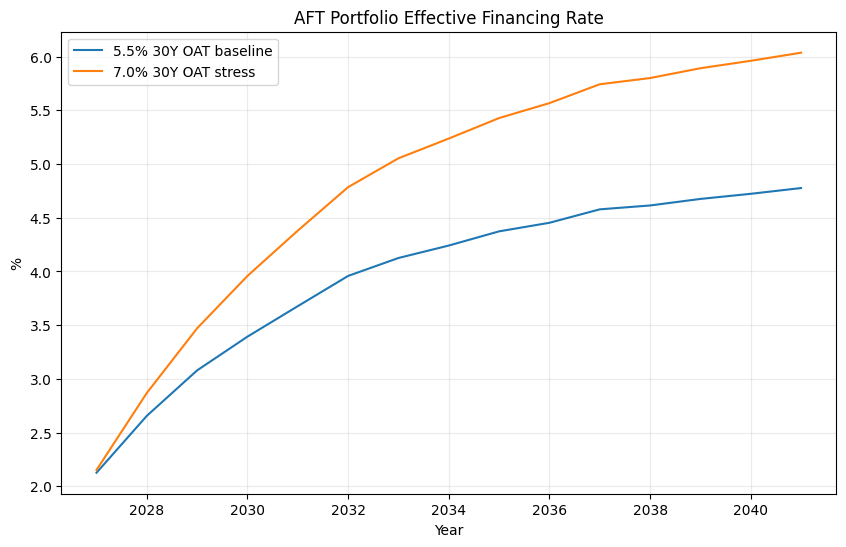

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    aft_baseline_path["year"],
    aft_baseline_path["effective_financing_rate"] * 100,
    label="5.5% 30Y OAT baseline",
)

ax.plot(
    aft_stress_path["year"],
    aft_stress_path["effective_financing_rate"] * 100,
    label="7.0% 30Y OAT stress",
)

ax.set_title("AFT Portfolio Effective Financing Rate")
ax.set_xlabel("Year")
ax.set_ylabel("%")
ax.legend()
ax.grid(alpha=0.25)

plt.show()

## 4. General-government DSA bridge

In [10]:
def simulate_general_government_dsa(
    years,
    initial_gdp_eur,
    initial_debt_gdp,
    baseline_effective_rate,
    nominal_growth,
    primary_balance_gdp,
    interest_cost_shock=None,
):
    years = list(years)

    def get_year_value(value, year):
        if np.isscalar(value):
            return float(value)
        if isinstance(value, pd.Series):
            return float(value.loc[year])
        if isinstance(value, dict):
            return float(value[year])
        raise TypeError(
            "Assumption must be a scalar, dict, or pandas Series."
        )

    gdp = float(initial_gdp_eur)
    debt = gdp * float(initial_debt_gdp)

    if interest_cost_shock is None:
        interest_cost_shock = pd.Series(0.0, index=years)

    results = []

    for year in years:
        growth = get_year_value(nominal_growth, year)
        primary_balance_ratio = get_year_value(primary_balance_gdp, year)
        effective_rate = get_year_value(baseline_effective_rate, year)
        shock_eur = get_year_value(interest_cost_shock, year)

        gdp_start = gdp
        debt_start = debt
        gdp_end = gdp_start * (1.0 + growth)

        baseline_interest_eur = debt_start * effective_rate
        total_interest_eur = baseline_interest_eur + shock_eur

        implied_effective_rate = (
            total_interest_eur / debt_start
            if debt_start > 0
            else 0.0
        )

        primary_balance_eur = primary_balance_ratio * gdp_end

        debt_end = (
            debt_start
            + total_interest_eur
            - primary_balance_eur
        )

        results.append({
            "year": year,
            "gdp_start_eur": gdp_start,
            "gdp_end_eur": gdp_end,
            "nominal_growth": growth,
            "debt_start_eur": debt_start,
            "debt_gdp_start": debt_start / gdp_start,
            "baseline_effective_rate": effective_rate,
            "baseline_interest_eur": baseline_interest_eur,
            "aft_interest_cost_shock_eur": shock_eur,
            "total_interest_eur": total_interest_eur,
            "implied_effective_rate": implied_effective_rate,
            "interest_gdp": total_interest_eur / gdp_end,
            "primary_balance_gdp": primary_balance_ratio,
            "primary_balance_eur": primary_balance_eur,
            "debt_end_eur": debt_end,
            "debt_gdp_end": debt_end / gdp_end,
        })

        gdp = gdp_end
        debt = debt_end

    return pd.DataFrame(results)

In [11]:
YEARS = aft_baseline_path["year"].astype(int).tolist()

aft_interest_cost_shock = (
    aft_comparison
    .set_index("year")["interest_cost_shock_eur"]
)

gg_baseline_path = simulate_general_government_dsa(
    years=YEARS,
    initial_gdp_eur=BASELINE["initial_gdp_eur"],
    initial_debt_gdp=BASELINE["initial_debt_gdp"],
    baseline_effective_rate=BASELINE["effective_interest_rate"],
    nominal_growth=BASELINE["nominal_growth"],
    primary_balance_gdp=BASELINE["initial_primary_balance_gdp"],
)

gg_stress_path = simulate_general_government_dsa(
    years=YEARS,
    initial_gdp_eur=BASELINE["initial_gdp_eur"],
    initial_debt_gdp=BASELINE["initial_debt_gdp"],
    baseline_effective_rate=BASELINE["effective_interest_rate"],
    nominal_growth=BASELINE["nominal_growth"],
    primary_balance_gdp=BASELINE["initial_primary_balance_gdp"],
    interest_cost_shock=aft_interest_cost_shock,
)

first_year = gg_baseline_path.iloc[0]

expected_debt_ratio = (
    (1 + BASELINE["effective_interest_rate"])
    / (1 + BASELINE["nominal_growth"])
    * BASELINE["initial_debt_gdp"]
    - BASELINE["initial_primary_balance_gdp"]
)

assert np.isclose(
    expected_debt_ratio,
    first_year["debt_gdp_end"],
    atol=1e-10,
)

print("Debt-dynamics validation passed.")

Debt-dynamics validation passed.


# 5. Historical calibration dataset

The stochastic model is calibrated on annual observations from **1999–2025**.

Variables:

- French real GDP growth
- French HICP inflation
- French general-government primary balance / GDP
- German 10Y Bund yield
- France–Germany 10Y sovereign spread

In [12]:
ECB_CACHE_DIR = RAW_DIR / "ecb"

def create_ecb_session():
    retry_strategy = Retry(
        total=6,
        connect=6,
        read=6,
        status=6,
        backoff_factor=1.5,
        status_forcelist=[429, 500, 502, 503, 504],
        allowed_methods=frozenset(["GET"]),
        respect_retry_after_header=True,
    )

    adapter = HTTPAdapter(max_retries=retry_strategy)
    session = requests.Session()
    session.mount("https://", adapter)
    session.mount("http://", adapter)

    session.headers.update({
        "Accept": "text/csv",
        "Accept-Encoding": "gzip, deflate",
        "User-Agent": "french-oat-model/1.0",
    })

    return session

ECB_SESSION = create_ecb_session()


def fetch_ecb_series(
    series_key,
    start_period="1999-01",
    end_period="2025-12",
    cache_dir=ECB_CACHE_DIR,
    force_refresh=False,
):
    cache_dir = Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)

    safe_key = (
        series_key
        .replace(".", "_")
        .replace("+", "_")
    )

    cache_path = (
        cache_dir
        / f"ecb_IRS_{safe_key}_{start_period}_{end_period}.csv"
    )

    if cache_path.exists() and not force_refresh:
        print(f"Loading cached ECB data:\n{cache_path}")
        return pd.read_csv(
            cache_path,
            parse_dates=["TIME_PERIOD"],
        )

    url = (
        "https://data-api.ecb.europa.eu/"
        f"service/data/IRS/{series_key}"
    )

    params = {
        "startPeriod": start_period,
        "endPeriod": end_period,
        "format": "csvdata",
        "detail": "dataonly",
    }

    response = ECB_SESSION.get(
        url,
        params=params,
        timeout=(10, 180),
    )
    response.raise_for_status()

    df = pd.read_csv(StringIO(response.text))

    required_columns = {"TIME_PERIOD", "OBS_VALUE"}
    missing = required_columns - set(df.columns)

    if missing:
        raise ValueError(
            f"ECB response missing columns: {missing}"
        )

    df["TIME_PERIOD"] = pd.to_datetime(
        df["TIME_PERIOD"],
        errors="coerce",
    )

    df["OBS_VALUE"] = pd.to_numeric(
        df["OBS_VALUE"],
        errors="coerce",
    )

    df = (
        df[["TIME_PERIOD", "OBS_VALUE"]]
        .dropna()
        .sort_values("TIME_PERIOD")
        .reset_index(drop=True)
    )

    df.to_csv(cache_path, index=False)
    return df

In [13]:
FRANCE_10Y_KEY = "M.FR.L.L40.CI.0000.EUR.N.Z"
GERMANY_10Y_KEY = "M.DE.L.L40.CI.0000.EUR.N.Z"

france_10y_monthly = fetch_ecb_series(
    FRANCE_10Y_KEY,
    start_period="1999-01",
    end_period="2025-12",
)

germany_10y_monthly = fetch_ecb_series(
    GERMANY_10Y_KEY,
    start_period="1999-01",
    end_period="2025-12",
)

def monthly_rate_to_annual(
    df,
    column_name,
):
    result = df.copy()
    result["year"] = result["TIME_PERIOD"].dt.year
    result[column_name] = (
        pd.to_numeric(
            result["OBS_VALUE"],
            errors="coerce",
        )
        / 100
    )

    return (
        result[["year", column_name]]
        .dropna()
        .groupby("year", as_index=False)[column_name]
        .mean()
    )

france_10y_annual = monthly_rate_to_annual(
    france_10y_monthly,
    "france_10y",
)

germany_10y_annual = monthly_rate_to_annual(
    germany_10y_monthly,
    "bund_10y",
)

rates_history = (
    france_10y_annual
    .merge(
        germany_10y_annual,
        on="year",
        how="inner",
        validate="one_to_one",
    )
)

rates_history["france_spread_10y"] = (
    rates_history["france_10y"]
    - rates_history["bund_10y"]
)

rates_history = (
    rates_history[
        rates_history["year"].between(1999, 2025)
    ]
    .sort_values("year")
    .reset_index(drop=True)
)

rates_history

Loading cached ECB data:
c:\Users\mikel\Desktop\french_oat_model\data\raw\ecb\ecb_IRS_M_FR_L_L40_CI_0000_EUR_N_Z_1999-01_2025-12.csv
Loading cached ECB data:
c:\Users\mikel\Desktop\french_oat_model\data\raw\ecb\ecb_IRS_M_DE_L_L40_CI_0000_EUR_N_Z_1999-01_2025-12.csv


,year,france_10y,bund_10y,france_spread_10y
0,1999,0.046192,0.044908,0.001283
1,2000,0.053942,0.052633,0.001308
2,2001,0.049392,0.047975,0.001417
3,2002,0.048600,0.047825,0.000775
4,2003,0.041300,0.040708,0.000592
5,2004,0.040983,0.040367,0.000617
6,2005,0.034100,0.033533,0.000567
7,2006,0.037967,0.037625,0.000342
8,2007,0.043042,0.042167,0.000875
9,2008,0.042342,0.039842,0.002500


In [14]:
EUROSTAT_CACHE_DIR = RAW_DIR / "eurostat"

def _jsonstat_category_labels(category_index):
    if isinstance(category_index, dict):
        return [
            label
            for label, _
            in sorted(
                category_index.items(),
                key=lambda x: x[1],
            )
        ]
    return list(category_index)


def fetch_eurostat_series(
    dataset_code,
    filters,
    value_name,
    cache_dir=EUROSTAT_CACHE_DIR,
    force_refresh=False,
):
    cache_dir = Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)

    filter_string = "_".join(
        f"{key}-{value}"
        for key, value
        in sorted(filters.items())
    )

    cache_path = (
        cache_dir
        / f"{dataset_code}_{filter_string}.csv"
    )

    if cache_path.exists() and not force_refresh:
        print(f"Loading cached Eurostat data:\n{cache_path}")
        return pd.read_csv(cache_path)

    url = (
        "https://ec.europa.eu/"
        "eurostat/api/dissemination/"
        "statistics/1.0/data/"
        f"{dataset_code}"
    )

    params = {
        "lang": "EN",
        **filters,
    }

    response = requests.get(
        url,
        params=params,
        timeout=(10, 180),
    )
    response.raise_for_status()
    data = response.json()

    dimension_ids = data["id"]
    dimension_sizes = data["size"]

    if "time" not in dimension_ids:
        raise ValueError(
            "Eurostat response contains no time dimension."
        )

    time_pos = dimension_ids.index("time")

    for i, dimension in enumerate(dimension_ids):
        if dimension != "time" and dimension_sizes[i] != 1:
            raise ValueError(
                f"Dimension {dimension!r} was not reduced to one category."
            )

    years = _jsonstat_category_labels(
        data["dimension"]["time"]["category"]["index"]
    )

    values = data["value"]
    rows = []

    for time_coordinate, year in enumerate(years):
        coordinates = [0 for _ in dimension_ids]
        coordinates[time_pos] = time_coordinate

        flat_index = int(
            np.ravel_multi_index(
                tuple(coordinates),
                tuple(dimension_sizes),
                order="C",
            )
        )

        if isinstance(values, dict):
            value = values.get(str(flat_index), np.nan)
        else:
            value = (
                values[flat_index]
                if flat_index < len(values)
                else np.nan
            )

        rows.append({
            "year": int(year),
            value_name: value,
        })

    result = pd.DataFrame(rows)
    result[value_name] = pd.to_numeric(
        result[value_name],
        errors="coerce",
    )

    result.to_csv(cache_path, index=False)
    return result

In [15]:
real_growth_history = fetch_eurostat_series(
    dataset_code="nama_10_gdp",
    filters={
        "freq": "A",
        "unit": "CLV_PCH_PRE",
        "na_item": "B1GQ",
        "geo": "FR",
    },
    value_name="real_growth",
)

real_growth_history["real_growth"] /= 100

real_growth_history = (
    real_growth_history[
        real_growth_history["year"].between(1999, 2025)
    ]
    .reset_index(drop=True)
)

inflation_history = fetch_eurostat_series(
    dataset_code="prc_hicp_aind",
    filters={
        "freq": "A",
        "unit": "RCH_A_AVG",
        "coicop": "CP00",
        "geo": "FR",
    },
    value_name="inflation",
)

inflation_history["inflation"] /= 100

inflation_history = (
    inflation_history[
        inflation_history["year"].between(1999, 2025)
    ]
    .reset_index(drop=True)
)

Loading cached Eurostat data:
c:\Users\mikel\Desktop\french_oat_model\data\raw\eurostat\nama_10_gdp_freq-A_geo-FR_na_item-B1GQ_unit-CLV_PCH_PRE.csv
Loading cached Eurostat data:
c:\Users\mikel\Desktop\french_oat_model\data\raw\eurostat\prc_hicp_aind_coicop-CP00_freq-A_geo-FR_unit-RCH_A_AVG.csv


In [16]:
DBNOMICS_CACHE_DIR = RAW_DIR / "ameco"

def fetch_ameco_primary_balance(
    cache_dir=DBNOMICS_CACHE_DIR,
    force_refresh=False,
):
    cache_dir = Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)

    cache_path = (
        cache_dir
        / "france_primary_balance_gdp.csv"
    )

    if cache_path.exists() and not force_refresh:
        print(f"Loading cached AMECO data:\n{cache_path}")
        return pd.read_csv(cache_path)

    series_code = "FRA.1.0.319.0.UBLGI"

    url = (
        "https://api.db.nomics.world/"
        "v22/series/"
        f"AMECO/UBLGI/{series_code}"
    )

    response = requests.get(
        url,
        params={"observations": 1},
        timeout=(10, 180),
    )
    response.raise_for_status()

    payload = response.json()

    docs = (
        payload
        .get("series", {})
        .get("docs", [])
    )

    if not docs:
        raise ValueError(
            "DBnomics returned no AMECO observations."
        )

    series = docs[0]

    result = pd.DataFrame({
        "year": pd.to_numeric(
            series["period"],
            errors="coerce",
        ),
        "primary_balance_gdp": pd.to_numeric(
            series["value"],
            errors="coerce",
        ),
    })

    result = result.dropna().copy()
    result["year"] = result["year"].astype(int)
    result["primary_balance_gdp"] /= 100

    result = (
        result[
            result["year"].between(1999, 2025)
        ]
        .reset_index(drop=True)
    )

    result.to_csv(cache_path, index=False)
    return result

primary_balance_history = (
    fetch_ameco_primary_balance()
)

Loading cached AMECO data:
c:\Users\mikel\Desktop\french_oat_model\data\raw\ameco\france_primary_balance_gdp.csv


In [17]:
macro_history = (
    real_growth_history
    .merge(
        inflation_history,
        on="year",
        how="inner",
    )
    .merge(
        primary_balance_history,
        on="year",
        how="inner",
    )
)

calibration_data = (
    macro_history
    .merge(
        rates_history[
            [
                "year",
                "bund_10y",
                "france_spread_10y",
            ]
        ],
        on="year",
        how="inner",
    )
)

CALIBRATION_START_YEAR = 1999
CALIBRATION_END_YEAR = 2025

CALIBRATION_VARIABLES = [
    "real_growth",
    "inflation",
    "primary_balance_gdp",
    "bund_10y",
    "france_spread_10y",
]

calibration_data = (
    calibration_data[
        calibration_data["year"].between(
            CALIBRATION_START_YEAR,
            CALIBRATION_END_YEAR,
        )
    ]
    .sort_values("year")
    .reset_index(drop=True)
)

expected_years = set(
    range(
        CALIBRATION_START_YEAR,
        CALIBRATION_END_YEAR + 1,
    )
)

missing_years = (
    expected_years
    - set(calibration_data["year"])
)

assert not missing_years, (
    f"Missing calibration years: {sorted(missing_years)}"
)

assert calibration_data["year"].is_unique

assert not (
    calibration_data[
        CALIBRATION_VARIABLES
    ]
    .isna()
    .any()
    .any()
)

assert len(calibration_data) == 27

print("Historical calibration dataset validation passed.")
calibration_data

Historical calibration dataset validation passed.


,year,real_growth,inflation,primary_balance_gdp,bund_10y,france_spread_10y
0,1999,0.034,0.006,0.015338,0.044908,0.001283
1,2000,0.041,0.018,0.016466,0.052633,0.001308
2,2001,0.019,0.018,0.016352,0.047975,0.001417
3,2002,0.011,0.019,-0.001475,0.047825,0.000775
4,2003,0.010,0.022,-0.012118,0.040708,0.000592
5,2004,0.029,0.023,-0.007540,0.040367,0.000617
6,2005,0.019,0.019,-0.007921,0.033533,0.000567
7,2006,0.027,0.019,-0.000543,0.037625,0.000342
8,2007,0.025,0.016,-0.003014,0.042167,0.000875
9,2008,0.004,0.032,-0.006292,0.039842,0.002500


## 6. AR(1) calibration and robust covariance

In [18]:
def estimate_ar1(
    series,
    variable_name,
):
    x = (
        pd.Series(series)
        .dropna()
        .astype(float)
        .to_numpy()
    )

    if len(x) < 10:
        raise ValueError(
            f"Too few observations for {variable_name}: {len(x)}"
        )

    y = x[1:]
    x_lag = x[:-1]

    X = np.column_stack([
        np.ones(len(x_lag)),
        x_lag,
    ])

    beta = np.linalg.lstsq(
        X,
        y,
        rcond=None,
    )[0]

    intercept = float(beta[0])
    rho = float(beta[1])

    fitted = (
        intercept
        + rho * x_lag
    )

    residuals = (
        y
        - fitted
    )

    degrees_of_freedom = len(residuals) - 2

    innovation_std = float(
        np.sqrt(
            np.sum(residuals ** 2)
            / degrees_of_freedom
        )
    )

    if abs(rho) < 1.0:
        long_run_mean = (
            intercept
            / (1.0 - rho)
        )
    else:
        long_run_mean = np.nan

    return {
        "variable": variable_name,
        "n_observations": len(x),
        "intercept": intercept,
        "rho": rho,
        "long_run_mean": long_run_mean,
        "innovation_std": innovation_std,
        "fitted": fitted,
        "residuals": residuals,
    }


ar1_results = {
    variable: estimate_ar1(
        calibration_data[variable],
        variable,
    )
    for variable
    in CALIBRATION_VARIABLES
}

ar1_summary = pd.DataFrame([
    {
        "variable": variable,
        "long_run_mean_pct": (
            result["long_run_mean"] * 100
        ),
        "rho": result["rho"],
        "innovation_std_pct": (
            result["innovation_std"] * 100
        ),
    }
    for variable, result
    in ar1_results.items()
])

ar1_summary.round(3)

,variable,long_run_mean_pct,rho,innovation_std_pct
0,real_growth,1.400,-0.242,2.393
1,inflation,1.891,0.460,1.258
2,primary_balance_gdp,-2.276,0.598,1.670
3,bund_10y,1.510,0.916,0.611
4,france_spread_10y,0.518,0.852,0.148


In [19]:
RESIDUAL_YEARS = (
    calibration_data["year"]
    .iloc[1:]
    .to_numpy()
)

residual_data = pd.DataFrame({
    variable:
        ar1_results[variable]["residuals"]
    for variable
    in CALIBRATION_VARIABLES
})

residual_data.insert(
    0,
    "year",
    RESIDUAL_YEARS,
)

RESIDUAL_MATRIX = (
    residual_data[
        CALIBRATION_VARIABLES
    ]
    .to_numpy(dtype=float)
)

raw_residual_correlation = (
    residual_data[
        CALIBRATION_VARIABLES
    ]
    .corr()
)

raw_residual_correlation.round(3)

,real_growth,inflation,primary_balance_gdp,bund_10y,france_spread_10y
real_growth,1.000,0.518,0.905,0.457,-0.005
inflation,0.518,1.000,0.406,0.604,0.200
primary_balance_gdp,0.905,0.406,1.000,0.297,-0.031
bund_10y,0.457,0.604,0.297,1.000,-0.035
france_spread_10y,-0.005,0.200,-0.031,-0.035,1.000


In [20]:
standardized_residuals = (
    residual_data[
        CALIBRATION_VARIABLES
    ]
    - residual_data[
        CALIBRATION_VARIABLES
    ].mean()
) / residual_data[
    CALIBRATION_VARIABLES
].std(ddof=1)

lw = LedoitWolf().fit(
    standardized_residuals.values
)

shrunk_covariance = lw.covariance_

std = np.sqrt(
    np.diag(shrunk_covariance)
)

CALIBRATED_CORRELATION_MATRIX = (
    shrunk_covariance
    / np.outer(std, std)
)

correlation_df = pd.DataFrame(
    CALIBRATED_CORRELATION_MATRIX,
    index=CALIBRATION_VARIABLES,
    columns=CALIBRATION_VARIABLES,
)

correlation_df.round(3)

,real_growth,inflation,primary_balance_gdp,bund_10y,france_spread_10y
real_growth,1.000,0.206,0.360,0.182,-0.002
inflation,0.206,1.000,0.162,0.241,0.080
primary_balance_gdp,0.360,0.162,1.000,0.118,-0.012
bund_10y,0.182,0.241,0.118,1.000,-0.014
france_spread_10y,-0.002,0.080,-0.012,-0.014,1.000


In [21]:
PERSISTENCE = {
    variable:
        ar1_results[variable]["rho"]
    for variable
    in CALIBRATION_VARIABLES
}

SHOCK_STD = {
    variable:
        ar1_results[variable]["innovation_std"]
    for variable
    in CALIBRATION_VARIABLES
}

shock_std_vector = np.array([
    SHOCK_STD[variable]
    for variable
    in CALIBRATION_VARIABLES
])

CALIBRATED_COVARIANCE_MATRIX = (
    np.outer(
        shock_std_vector,
        shock_std_vector,
    )
    * CALIBRATED_CORRELATION_MATRIX
)

assert (
    np.linalg.eigvalsh(
        CALIBRATED_COVARIANCE_MATRIX
    ) > 0
).all()

print(
    "Ledoit-Wolf covariance matrix is positive definite."
)

Ledoit-Wolf covariance matrix is positive definite.


In [22]:
# Preferred ordinary-times covariance:
# Minimum Covariance Determinant (robust to crisis outliers).

X = residual_data[
    CALIBRATION_VARIABLES
].to_numpy(dtype=float)

mcd = MinCovDet(
    random_state=RANDOM_SEED
).fit(X)

ROBUST_RESIDUAL_MEAN = (
    mcd.location_
)

ROBUST_COVARIANCE_MATRIX = (
    mcd.covariance_
)

robust_eigenvalues = (
    np.linalg.eigvalsh(
        ROBUST_COVARIANCE_MATRIX
    )
)

assert (
    robust_eigenvalues > 0
).all()

robust_std = np.sqrt(
    np.diag(
        ROBUST_COVARIANCE_MATRIX
    )
)

volatility_comparison = pd.DataFrame({
    "variable":
        CALIBRATION_VARIABLES,

    "full_sample_std_pct":
        [
            SHOCK_STD[x] * 100
            for x
            in CALIBRATION_VARIABLES
        ],

    "robust_std_pct":
        robust_std * 100,
})

volatility_comparison.round(3)

,variable,full_sample_std_pct,robust_std_pct
0,real_growth,2.393,1.018
1,inflation,1.258,0.614
2,primary_balance_gdp,1.670,0.747
3,bund_10y,0.611,0.502
4,france_spread_10y,0.148,0.070


In [23]:
robust_distance_squared = (
    mcd.mahalanobis(X)
)

OUTLIER_CONFIDENCE = 0.975

outlier_threshold = chi2.ppf(
    OUTLIER_CONFIDENCE,
    df=len(CALIBRATION_VARIABLES),
)

residual_diagnostics = (
    residual_data.copy()
)

residual_diagnostics[
    "robust_mahalanobis_sq"
] = robust_distance_squared

residual_diagnostics[
    "stress_observation"
] = (
    residual_diagnostics[
        "robust_mahalanobis_sq"
    ]
    > outlier_threshold
)

residual_diagnostics[
    [
        "year",
        "robust_mahalanobis_sq",
        "stress_observation",
    ]
].sort_values(
    "robust_mahalanobis_sq",
    ascending=False,
)

,year,robust_mahalanobis_sq,stress_observation
20,2020,169.551371,True
22,2022,68.183658,True
12,2012,65.818649,True
9,2009,55.669435,True
11,2011,46.621560,True
21,2021,40.889382,True
8,2008,34.523055,True
13,2013,30.704266,True
23,2023,29.645189,True
25,2025,24.242640,True


## 7. Time-varying central scenario

In [24]:
# Latest market state from 2026 ECB observations.

france_10y_current = fetch_ecb_series(
    FRANCE_10Y_KEY,
    start_period="2026-01",
    end_period="2026-10",
)

germany_10y_current = fetch_ecb_series(
    GERMANY_10Y_KEY,
    start_period="2026-01",
    end_period="2026-10",
)

latest_france_row = (
    france_10y_current
    .sort_values("TIME_PERIOD")
    .iloc[-1]
)

latest_germany_row = (
    germany_10y_current
    .sort_values("TIME_PERIOD")
    .iloc[-1]
)

CURRENT_FRANCE_10Y = (
    latest_france_row["OBS_VALUE"] / 100
)

CURRENT_BUND_10Y = (
    latest_germany_row["OBS_VALUE"] / 100
)

CURRENT_FRANCE_SPREAD_10Y = (
    CURRENT_FRANCE_10Y
    - CURRENT_BUND_10Y
)

print(f"France 10Y: {CURRENT_FRANCE_10Y:.2%}")
print(f"Bund 10Y: {CURRENT_BUND_10Y:.2%}")
print(f"France spread: {CURRENT_FRANCE_SPREAD_10Y:.2%}")

Loading cached ECB data:
c:\Users\mikel\Desktop\french_oat_model\data\raw\ecb\ecb_IRS_M_FR_L_L40_CI_0000_EUR_N_Z_2026-01_2026-10.csv
Loading cached ECB data:
c:\Users\mikel\Desktop\french_oat_model\data\raw\ecb\ecb_IRS_M_DE_L_L40_CI_0000_EUR_N_Z_2026-01_2026-10.csv
France 10Y: 4.00%
Bund 10Y: 3.19%
France spread: 0.81%


In [25]:
def build_ar1_expected_path(
    initial_value,
    long_run_mean,
    rho,
    years,
):
    previous = float(initial_value)
    result = {}

    for year in years:
        current = (
            long_run_mean
            + rho
            * (
                previous
                - long_run_mean
            )
        )

        result[year] = current
        previous = current

    return result


CENTRAL_START_YEAR = 2026
CENTRAL_END_YEAR = 2041

CENTRAL_YEARS = list(
    range(
        CENTRAL_START_YEAR,
        CENTRAL_END_YEAR + 1,
    )
)

SIMULATION_YEARS = list(
    range(
        2027,
        CENTRAL_END_YEAR + 1,
    )
)

bund_expected = build_ar1_expected_path(
    initial_value=CURRENT_BUND_10Y,
    long_run_mean=(
        ar1_results[
            "bund_10y"
        ]["long_run_mean"]
    ),
    rho=PERSISTENCE["bund_10y"],
    years=SIMULATION_YEARS,
)

spread_expected = build_ar1_expected_path(
    initial_value=CURRENT_FRANCE_SPREAD_10Y,
    long_run_mean=(
        ar1_results[
            "france_spread_10y"
        ]["long_run_mean"]
    ),
    rho=PERSISTENCE[
        "france_spread_10y"
    ],
    years=SIMULATION_YEARS,
)

In [26]:
REAL_GROWTH_CENTRAL = {
    2026: 0.004,
    2027: 0.009,
    2028: 0.012,
    2029: 0.011,
    2030: 0.011,
    2031: 0.011,
}

INFLATION_CENTRAL = {
    2026: 0.023,
    2027: 0.019,
    2028: 0.016,
}

PRIMARY_BALANCE_CENTRAL = {
    2026: -0.027,
    2027: -0.023,
    2028: -0.017,
    2029: -0.011,
    2030: -0.006,
    2031: 0.000,
}

ECB_INFLATION_TARGET = 0.020

inflation_transition_years = [
    2029,
    2030,
    2031,
]

inflation_transition = np.linspace(
    INFLATION_CENTRAL[2028],
    ECB_INFLATION_TARGET,
    len(
        inflation_transition_years
    ) + 1,
)[1:]

for year, value in zip(
    inflation_transition_years,
    inflation_transition,
):
    INFLATION_CENTRAL[
        year
    ] = float(value)

for year in range(
    2032,
    CENTRAL_END_YEAR + 1,
):
    REAL_GROWTH_CENTRAL[
        year
    ] = REAL_GROWTH_CENTRAL[2031]

    INFLATION_CENTRAL[
        year
    ] = ECB_INFLATION_TARGET

    PRIMARY_BALANCE_CENTRAL[
        year
    ] = PRIMARY_BALANCE_CENTRAL[2031]

In [27]:
central_path = pd.DataFrame({
    "year": CENTRAL_YEARS,
})

central_path[
    "real_growth"
] = central_path[
    "year"
].map(
    REAL_GROWTH_CENTRAL
)

central_path[
    "inflation"
] = central_path[
    "year"
].map(
    INFLATION_CENTRAL
)

central_path[
    "primary_balance_gdp"
] = central_path[
    "year"
].map(
    PRIMARY_BALANCE_CENTRAL
)

bund_central = {
    2026: CURRENT_BUND_10Y,
    **bund_expected,
}

spread_central = {
    2026: CURRENT_FRANCE_SPREAD_10Y,
    **spread_expected,
}

central_path[
    "bund_10y"
] = central_path[
    "year"
].map(
    bund_central
)

central_path[
    "france_spread_10y"
] = central_path[
    "year"
].map(
    spread_central
)

central_path[
    "france_10y"
] = (
    central_path[
        "bund_10y"
    ]
    +
    central_path[
        "france_spread_10y"
    ]
)

INITIAL_10S30S_SLOPE = (
    BASELINE_OAT_30Y
    - CURRENT_FRANCE_10Y
)

central_path[
    "oat_30y"
] = (
    central_path[
        "france_10y"
    ]
    +
    INITIAL_10S30S_SLOPE
)

central_path[
    "nominal_growth"
] = (
    (
        1
        + central_path[
            "real_growth"
        ]
    )
    *
    (
        1
        + central_path[
            "inflation"
        ]
    )
    - 1
)

required_central_columns = [
    "real_growth",
    "inflation",
    "primary_balance_gdp",
    "bund_10y",
    "france_spread_10y",
    "france_10y",
    "oat_30y",
    "nominal_growth",
]

assert not (
    central_path[
        required_central_columns
    ]
    .isna()
    .any()
    .any()
)

print(
    "Central path validation passed."
)

central_path

Central path validation passed.


,year,real_growth,inflation,primary_balance_gdp,bund_10y,france_spread_10y,france_10y,oat_30y,nominal_growth
0,2026,0.004,0.023000,-0.027,0.031850,0.008150,0.040000,0.055000,0.027092
1,2027,0.009,0.019000,-0.023,0.030441,0.007709,0.038150,0.053150,0.028171
2,2028,0.012,0.016000,-0.017,0.029150,0.007333,0.036483,0.051483,0.028192
3,2029,0.011,0.017333,-0.011,0.027967,0.007014,0.034981,0.049981,0.028524
4,2030,0.011,0.018667,-0.006,0.026885,0.006741,0.033626,0.048626,0.029872
5,2031,0.011,0.020000,0.000,0.025893,0.006509,0.032402,0.047402,0.031220
6,2032,0.011,0.020000,0.000,0.024985,0.006311,0.031296,0.046296,0.031220
7,2033,0.011,0.020000,0.000,0.024153,0.006143,0.030296,0.045296,0.031220
8,2034,0.011,0.020000,0.000,0.023391,0.006000,0.029391,0.044391,0.031220
9,2035,0.011,0.020000,0.000,0.022693,0.005877,0.028571,0.043571,0.031220


## 8. Robust stochastic path

In [ ]:
def draw_empirical_innovation(
    rng,
):
    index = rng.integers(
        low=0,
        high=len(
            RESIDUAL_MATRIX
        ),
    )

    return (
        RESIDUAL_MATRIX[
            index
        ].copy()
    )


def generate_calibrated_stochastic_path(
    central_path,
    rng,
    innovation_method="robust_gaussian",
):
    central = (
        central_path
        .set_index("year")
        .copy()
    )

    years = [
        year
        for year in central.index
        if year >= 2027
    ]

    previous = {
        variable:
            float(
                central.loc[
                    2026,
                    variable,
                ]
            )
        for variable
        in CALIBRATION_VARIABLES
    }

    rows = []

    for year in years:
        previous_year = year - 1

        if innovation_method == "robust_gaussian":
            shocks = rng.multivariate_normal(
                mean=np.zeros(len(CALIBRATION_VARIABLES)),
                cov=ROBUST_COVARIANCE_MATRIX,
            )
        elif innovation_method == "gaussian":
            shocks = rng.multivariate_normal(
                mean=np.zeros(
                    len(
                        CALIBRATION_VARIABLES
                    )
                ),
                cov=CALIBRATED_COVARIANCE_MATRIX,
            )

        elif innovation_method == "bootstrap":
            shocks = (
                draw_empirical_innovation(
                    rng
                )
            )

        else:
            raise ValueError(
                "innovation_method must be "
                "'robust_gaussian', 'gaussian', or 'bootstrap'."
            )

        current = {}

        for i, variable in enumerate(
            CALIBRATION_VARIABLES
        ):
            mu_t = float(
                central.loc[
                    year,
                    variable,
                ]
            )

            mu_previous = float(
                central.loc[
                    previous_year,
                    variable,
                ]
            )

            rho = PERSISTENCE[
                variable
            ]

            current[
                variable
            ] = (
                mu_t
                +
                rho
                * (
                    previous[
                        variable
                    ]
                    - mu_previous
                )
                +
                shocks[i]
            )

        france_10y = (
            current[
                "bund_10y"
            ]
            +
            current[
                "france_spread_10y"
            ]
        )

        oat_30y = (
            france_10y
            +
            INITIAL_10S30S_SLOPE
        )

        nominal_growth = (
            (
                1
                + current[
                    "real_growth"
                ]
            )
            *
            (
                1
                + current[
                    "inflation"
                ]
            )
            - 1
        )

        rows.append({
            "year": year,
            **current,
            "france_10y": france_10y,
            "oat_30y": oat_30y,
            "nominal_growth": nominal_growth,
        })

        previous = current

    return pd.DataFrame(rows)

In [37]:
rng = np.random.default_rng(
    RANDOM_SEED
)

stochastic_path = (
    generate_calibrated_stochastic_path(
        central_path=central_path,
        rng=rng,
        innovation_method="robust_gaussian",
    )
)

stochastic_path

,year,real_growth,inflation,primary_balance_gdp,bund_10y,france_spread_10y,france_10y,oat_30y,nominal_growth
0,2027,0.007599,0.022953,-0.030084,0.029722,0.006793,0.036515,0.051515,0.030727
1,2028,0.024758,0.021452,-0.011708,0.032811,0.005953,0.038764,0.053764,0.046741
2,2029,0.001457,0.013536,-0.013199,0.024759,0.006315,0.031074,0.046074,0.015013
3,2030,0.021478,0.019090,0.001461,0.022996,0.005897,0.028893,0.043893,0.040978
4,2031,0.011717,0.022795,0.000243,0.026565,0.005883,0.032448,0.047448,0.034780
5,2032,0.015983,0.019346,0.001616,0.026267,0.006254,0.032520,0.047520,0.035638
6,2033,-0.013733,0.015582,-0.010706,0.018186,0.006159,0.024345,0.039345,0.001635
7,2034,0.003129,0.015781,-0.010034,0.013780,0.006015,0.019795,0.034795,0.018960
8,2035,0.005129,0.013856,-0.007590,0.008592,0.005801,0.014392,0.029392,0.019057
9,2036,0.012332,0.012007,-0.005823,0.006372,0.005977,0.012349,0.027349,0.024487


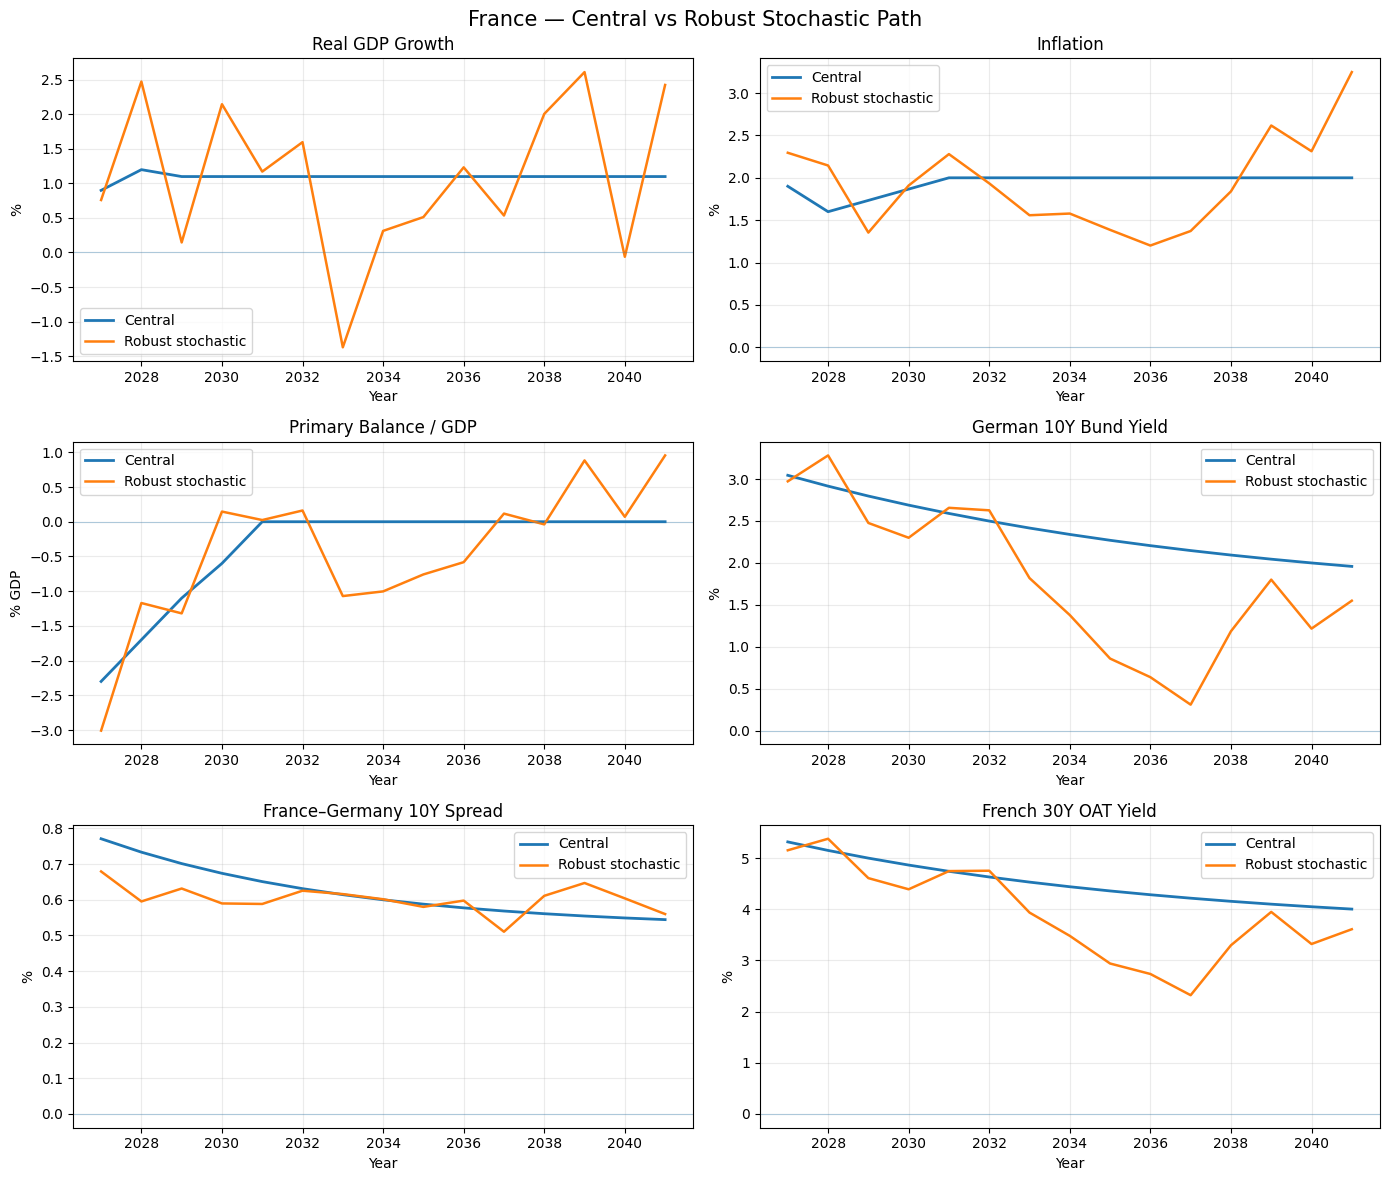

In [38]:
central_plot = (
    central_path[
        central_path["year"] >= 2027
    ]
    .copy()
    .reset_index(drop=True)
)

plot_specs = [
    ("real_growth", "Real GDP Growth", "%"),
    ("inflation", "Inflation", "%"),
    ("primary_balance_gdp", "Primary Balance / GDP", "% GDP"),
    ("bund_10y", "German 10Y Bund Yield", "%"),
    ("france_spread_10y", "France–Germany 10Y Spread", "%"),
    ("oat_30y", "French 30Y OAT Yield", "%"),
]

fig, axes = plt.subplots(
    3,
    2,
    figsize=(14, 12),
)

axes = axes.flatten()

for ax, (
    column,
    title,
    ylabel,
) in zip(
    axes,
    plot_specs,
):
    ax.plot(
        central_plot["year"],
        central_plot[column] * 100,
        label="Central",
        linewidth=2,
    )

    ax.plot(
        stochastic_path["year"],
        stochastic_path[column] * 100,
        label="Robust stochastic",
        linewidth=1.8,
    )

    ax.axhline(
        0,
        linewidth=0.8,
        alpha=0.3,
    )

    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)
    ax.legend()

fig.suptitle(
    "France — Central vs Robust Stochastic Path",
    fontsize=15,
)

plt.tight_layout()
plt.show()

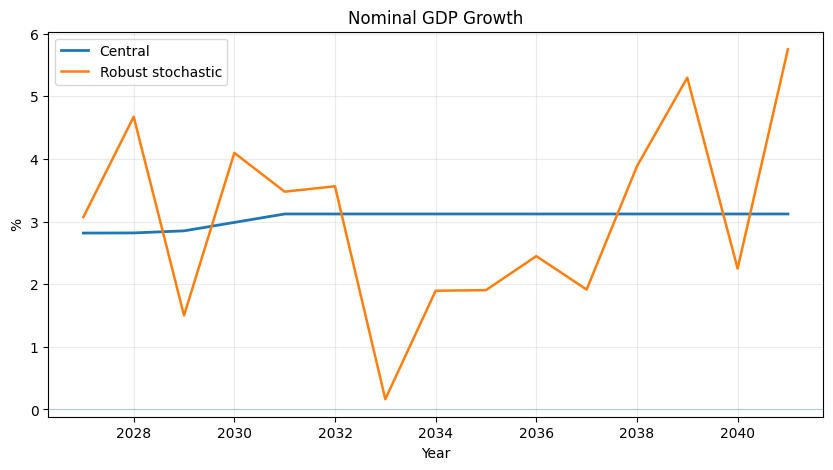

In [39]:
fig, ax = plt.subplots(
    figsize=(10, 5)
)

ax.plot(
    central_plot["year"],
    central_plot["nominal_growth"] * 100,
    label="Central",
    linewidth=2,
)

ax.plot(
    stochastic_path["year"],
    stochastic_path["nominal_growth"] * 100,
    label="Robust stochastic",
    linewidth=1.8,
)

ax.axhline(
    0,
    linewidth=0.8,
    alpha=0.3,
)

ax.set_title("Nominal GDP Growth")
ax.set_xlabel("Year")
ax.set_ylabel("%")
ax.grid(alpha=0.25)
ax.legend()

plt.show()

## 9. Feed the robust stochastic path through the AFT and GG engines

In [40]:
def build_stochastic_market_curves(
    stochastic_path,
):
    result = {}

    for _, row in stochastic_path.iterrows():
        year = int(row["year"])
        oat_30y = float(row["oat_30y"])

        nominal_curve = curve_from_30y_anchor(
            oat_30y_yield=oat_30y,
            offsets_to_30y=NOMINAL_CURVE_OFFSETS_TO_30Y,
        )

        yield_shift = (
            oat_30y
            - BASELINE_OAT_30Y
        )

        real_euro_curve = {
            maturity:
                rate
                + yield_shift
            for maturity, rate
            in baseline_real_euro_curve.items()
        }

        real_fr_curve = {
            maturity:
                rate
                + yield_shift
            for maturity, rate
            in baseline_real_fr_curve.items()
        }

        result[year] = {
            "nominal": nominal_curve,
            "real_euro": real_euro_curve,
            "real_fr": real_fr_curve,
        }

    return result


stochastic_indexed = (
    stochastic_path
    .set_index("year")
)

stochastic_nominal_growth = (
    stochastic_indexed[
        "nominal_growth"
    ]
)

stochastic_primary_balance = (
    stochastic_indexed[
        "primary_balance_gdp"
    ]
)

stochastic_inflation = (
    stochastic_indexed[
        "inflation"
    ]
)

stochastic_market_curves = (
    build_stochastic_market_curves(
        stochastic_path
    )
)

In [41]:
aft_stochastic_path, aft_stochastic_final = (
    simulate_portfolio_path(
        initial_portfolio=portfolio,
        initial_gdp_eur=BASELINE["initial_gdp_eur"],
        start_year=BASELINE["start_year"],
        years=BASELINE["horizon_years"],
        nominal_growth=(
            stochastic_nominal_growth.to_dict()
        ),
        primary_balance_ratio=(
            stochastic_primary_balance.to_dict()
        ),
        market_curves=stochastic_market_curves,
        issuance_plan=ISSUANCE_PLAN,
        french_inflation=(
            stochastic_inflation.to_dict()
        ),
        euro_inflation=(
            stochastic_inflation.to_dict()
        ),
    )
)

aft_stochastic_path[
    [
        "year",
        "weighted_market_issue_rate",
        "effective_financing_rate",
        "indexation_accrual_eur",
        "total_financing_cost_eur",
    ]
]

,year,weighted_market_issue_rate,effective_financing_rate,indexation_accrual_eur,total_financing_cost_eur
0,2027,0.042700,0.021653,7.288462e+09,6.340470e+10
1,2028,0.044949,0.026341,7.079783e+09,7.753146e+10
2,2029,0.037259,0.029199,4.697552e+09,8.928136e+10
3,2030,0.035078,0.031536,6.562835e+09,1.006152e+11
4,2031,0.038633,0.033467,8.152687e+09,1.099806e+11
5,2032,0.038705,0.035163,7.331506e+09,1.193884e+11
6,2033,0.030530,0.035638,5.965741e+09,1.250495e+11
7,2034,0.025980,0.035289,6.686306e+09,1.296494e+11
8,2035,0.020577,0.034627,6.258796e+09,1.330016e+11
9,2036,0.018534,0.033091,5.950681e+09,1.324623e+11


In [42]:
stochastic_aft_cost_shock = pd.Series(
    (
        aft_stochastic_path[
            "total_financing_cost_eur"
        ].to_numpy()
        -
        aft_baseline_path[
            "total_financing_cost_eur"
        ].to_numpy()
    ),
    index=YEARS,
)

gg_stochastic_path = (
    simulate_general_government_dsa(
        years=YEARS,
        initial_gdp_eur=BASELINE["initial_gdp_eur"],
        initial_debt_gdp=BASELINE["initial_debt_gdp"],
        baseline_effective_rate=BASELINE["effective_interest_rate"],
        nominal_growth=stochastic_nominal_growth,
        primary_balance_gdp=stochastic_primary_balance,
        interest_cost_shock=stochastic_aft_cost_shock,
    )
)

gg_stochastic_path[
    [
        "year",
        "nominal_growth",
        "primary_balance_gdp",
        "implied_effective_rate",
        "interest_gdp",
        "debt_gdp_end",
    ]
]

,year,nominal_growth,primary_balance_gdp,implied_effective_rate,interest_gdp,debt_gdp_end
0,2027,0.030727,-0.030084,0.023216,0.026758,1.209427
1,2028,0.046741,-0.011708,0.022827,0.026374,1.193503
2,2029,0.015013,-0.013199,0.021414,0.025180,1.214229
3,2030,0.040978,0.001461,0.020367,0.023756,1.188726
4,2031,0.034780,0.000243,0.018684,0.021463,1.169992
5,2032,0.035638,0.001616,0.016648,0.018808,1.146922
6,2033,0.001635,-0.010706,0.014344,0.016424,1.172180
7,2034,0.018960,-0.010034,0.012081,0.013897,1.174300
8,2035,0.019057,-0.007590,0.009142,0.010534,1.170465
9,2036,0.024487,-0.005823,0.005575,0.006370,1.154682


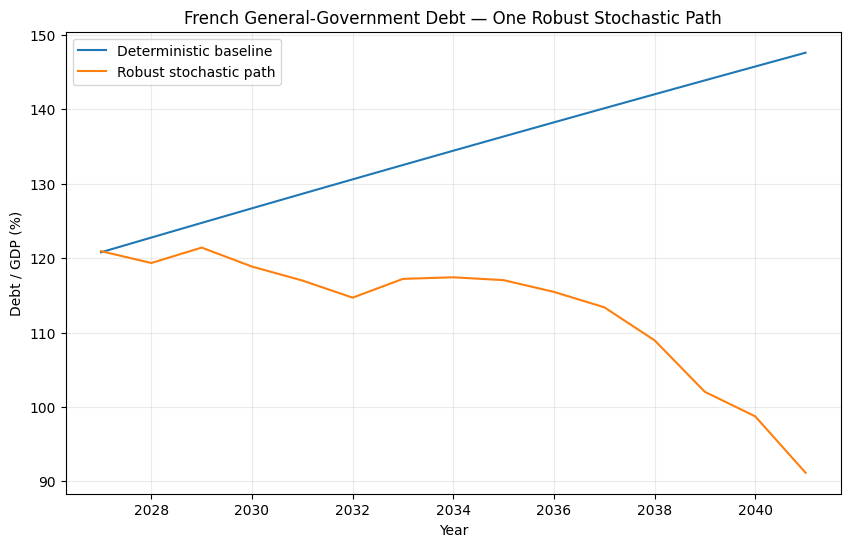

In [44]:
fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.plot(
    gg_baseline_path["year"],
    gg_baseline_path["debt_gdp_end"] * 100,
    label="Deterministic baseline",
)

ax.plot(
    gg_stochastic_path["year"],
    gg_stochastic_path["debt_gdp_end"] * 100,
    label="Robust stochastic path",
)

ax.set_title(
    "French General-Government Debt — One Robust Stochastic Path"
)

ax.set_xlabel("Year")
ax.set_ylabel("Debt / GDP (%)")
ax.legend()
ax.grid(alpha=0.25)

plt.show()

# Current stopping point

This notebook now contains the cleaned and consolidated work completed so far:

- validated AFT portfolio loading;
- deterministic AFT baseline and 7% OAT stress;
- deterministic general-government DSA bridge;
- historical 1999–2025 macro/market calibration;
- AR(1) persistence and innovation-volatility estimation;
- Ledoit–Wolf residual dependence;
- robust Minimum Covariance Determinant ordinary-times covariance;
- explicit identification of historical multivariate stress observations;
- time-varying central scenario;
- one robust stochastic path;
- transmission of that path through both the AFT and general-government debt engines.

The next stage is the full Monte Carlo engine and fan-chart / probability outputs.

In [45]:
debt_diag = gg_stochastic_path[
    [
        "year",
        "nominal_growth",
        "primary_balance_gdp",
        "implied_effective_rate",
        "interest_gdp",
        "debt_gdp_end",
    ]
].copy()

for col in [
    "nominal_growth",
    "primary_balance_gdp",
    "implied_effective_rate",
    "interest_gdp",
    "debt_gdp_end",
]:
    debt_diag[col] = debt_diag[col] * 100

debt_diag.round(2)

,year,nominal_growth,primary_balance_gdp,implied_effective_rate,interest_gdp,debt_gdp_end
0,2027,3.07,-3.01,2.32,2.68,120.94
1,2028,4.67,-1.17,2.28,2.64,119.35
2,2029,1.50,-1.32,2.14,2.52,121.42
3,2030,4.10,0.15,2.04,2.38,118.87
4,2031,3.48,0.02,1.87,2.15,117.00
5,2032,3.56,0.16,1.66,1.88,114.69
6,2033,0.16,-1.07,1.43,1.64,117.22
7,2034,1.90,-1.00,1.21,1.39,117.43
8,2035,1.91,-0.76,0.91,1.05,117.05
9,2036,2.45,-0.58,0.56,0.64,115.47


In [ ]:
decomp = gg_stochastic_path[
    [
        "year",
        "debt_gdp_start",
        "nominal_growth",
        "primary_balance_gdp",
        "interest_gdp",
        "debt_gdp_end",
    ]
].copy()

decomp["snowball_effect"] = (
    decomp["interest_gdp"]
    - decomp["nominal_growth"] * decomp["debt_gdp_start"] / (1 + decomp["nominal_growth"])
)

decomp["pb_effect"] = -decomp["primary_balance_gdp"]

for col in [
    "debt_gdp_start",
    "nominal_growth",
    "primary_balance_gdp",
    "interest_gdp",
    "snowball_effect",
    "pb_effect",
    "debt_gdp_end",
]:
    decomp[col] *= 100

decomp.round(2)